In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from honeybee_comb_inferer.inference import HoneyBeeCombInferer
from pathlib import Path
import segmentation_models_pytorch as smp
import cv2
import matplotlib.pyplot as plt

In [3]:
root_dir = Path().cwd().resolve().parent.parent
# path = Path(r"E:\Bachelorarbeit\2025-comb-images_Konstanz\cam-1\background_cam-1_20250731T201800.106175.142Z--20250731T201900.28054.402Z.png")
# path = Path(r"E:\Bachelorarbeit\2025-comb-images\cam-1\background_cam-1_20250808T233701.976714.862Z.png")
path = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\images\20240529_cam-2.png")
assert path.is_file()
model_dir = root_dir  / 'models'
model_name = 'unet_effnetb0'
device = 'cuda'

(<Figure size 3600x2800 with 2 Axes>,
 array([<Axes: title={'center': 'input image'}>,
        <Axes: title={'center': 'predicted'}>], dtype=object))

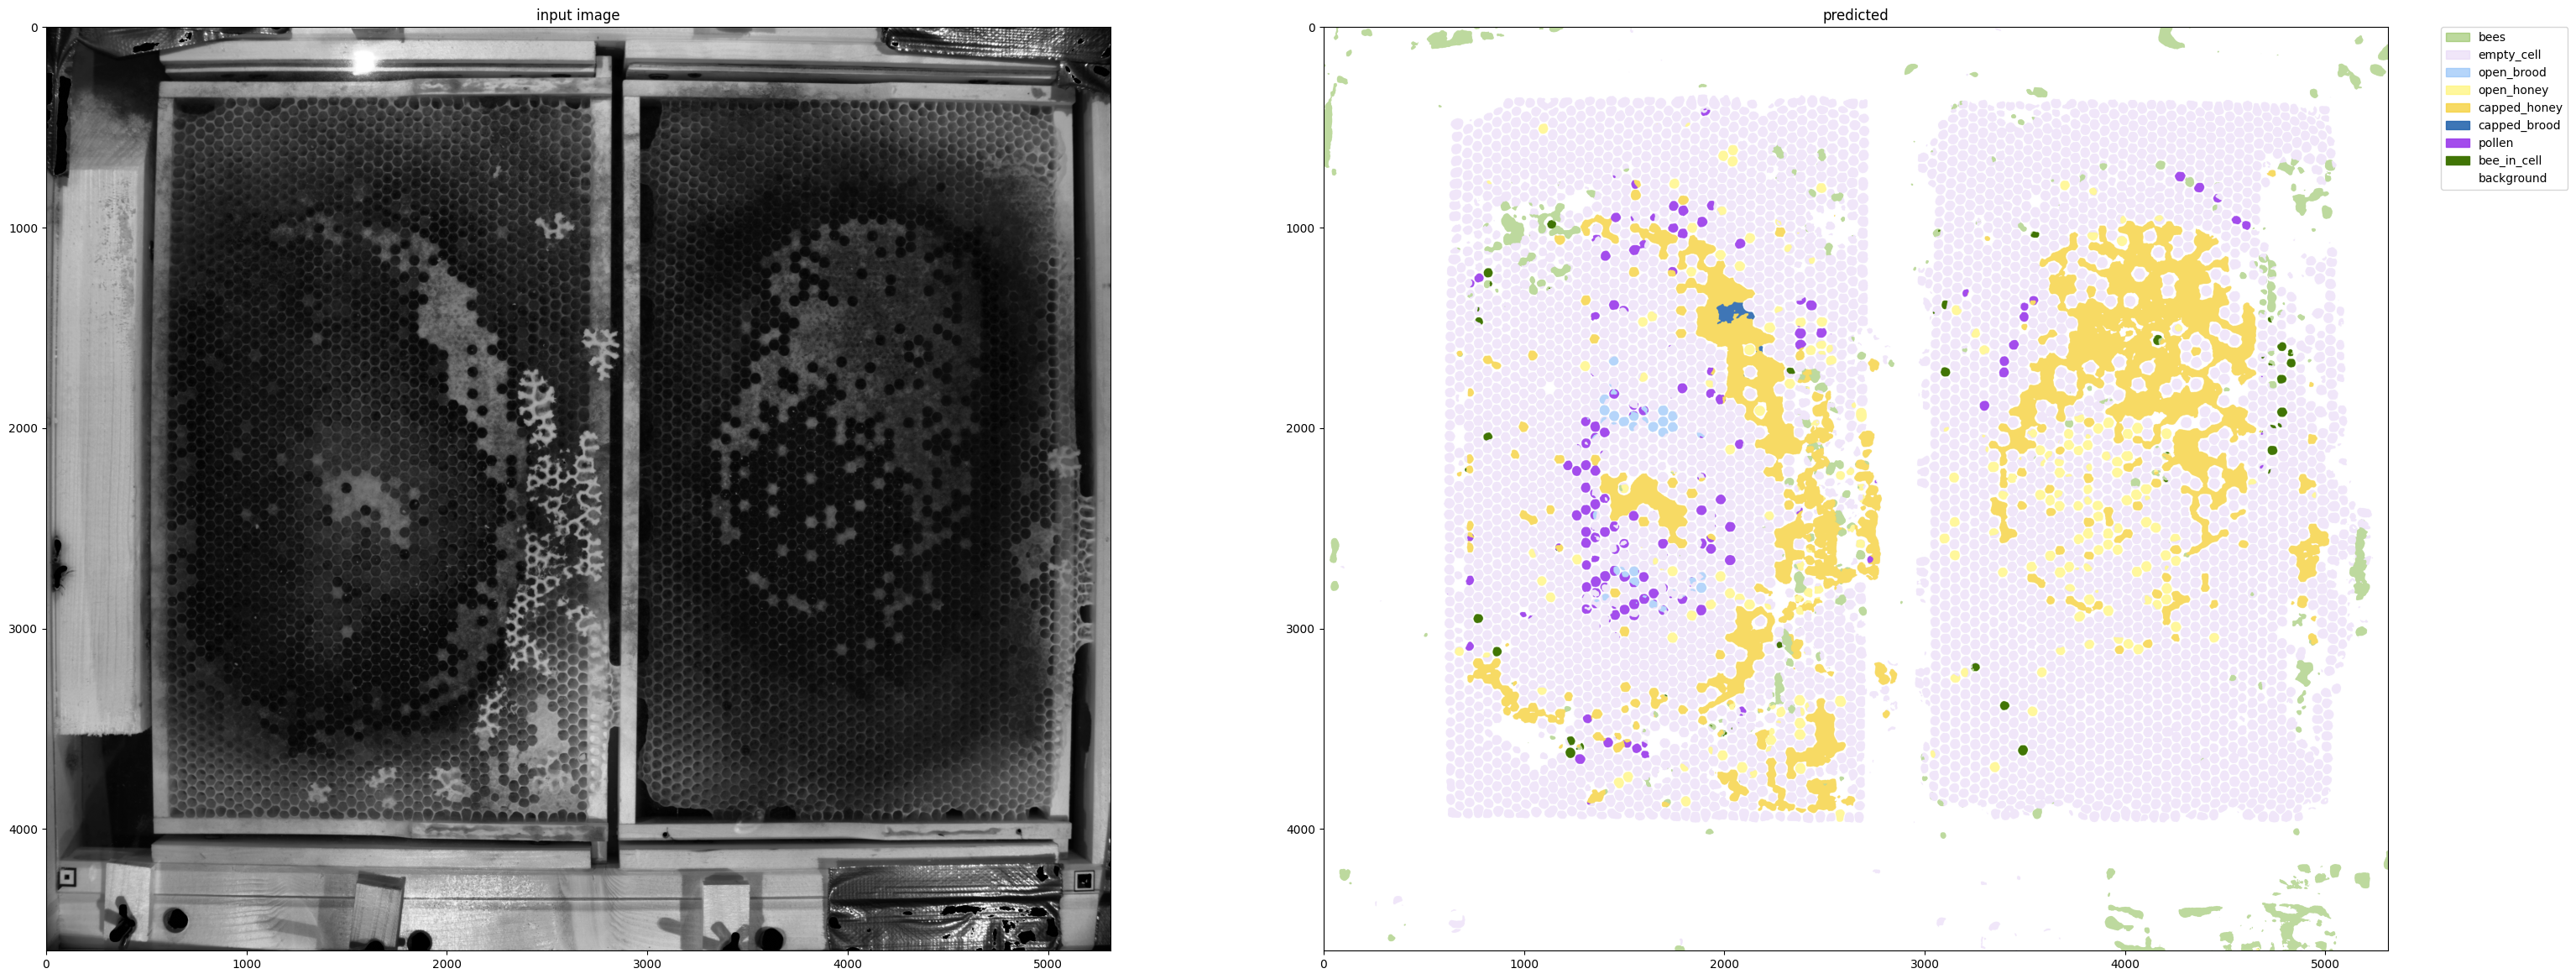

In [4]:
model = model = HoneyBeeCombInferer(model_name=model_name, path_to_pretrained_models=model_dir, device=device)
pred = model.infer(image=str(path))
model.plot_prediction(pred, input_image=str(path))

# Generate Binary Comb Mask

Now we'll use the CombMaskGenerator to create a binary mask that represents the entire comb structure (all cell types combined), with morphological closing to fill gaps between cells.

In [5]:
import sys
sys.path.append(str(root_dir))

from segmentation_restruct.comb_limitor import CombMaskGenerator

In [6]:
# Create generator with custom parameters
# closing_kernel_size: larger values fill bigger gaps (try 5, 7, 9, or 11)
# closing_iterations: more iterations = more aggressive filling
generator = CombMaskGenerator(
    closing_kernel_size=11,
    closing_iterations=3
)

In [7]:
# Generate binary comb mask from the segmentation
comb_mask = generator.generate_comb_mask(pred)

# Get statistics
stats = generator.get_comb_statistics(comb_mask)
print(f"Comb coverage: {stats['comb_percentage']:.1f}%")
print(f"Comb pixels: {stats['comb_pixels']:,}")
print(f"Number of comb regions: {stats['num_connected_components']}")

Comb coverage: 56.4%
Comb pixels: 13,814,754
Number of comb regions: 55


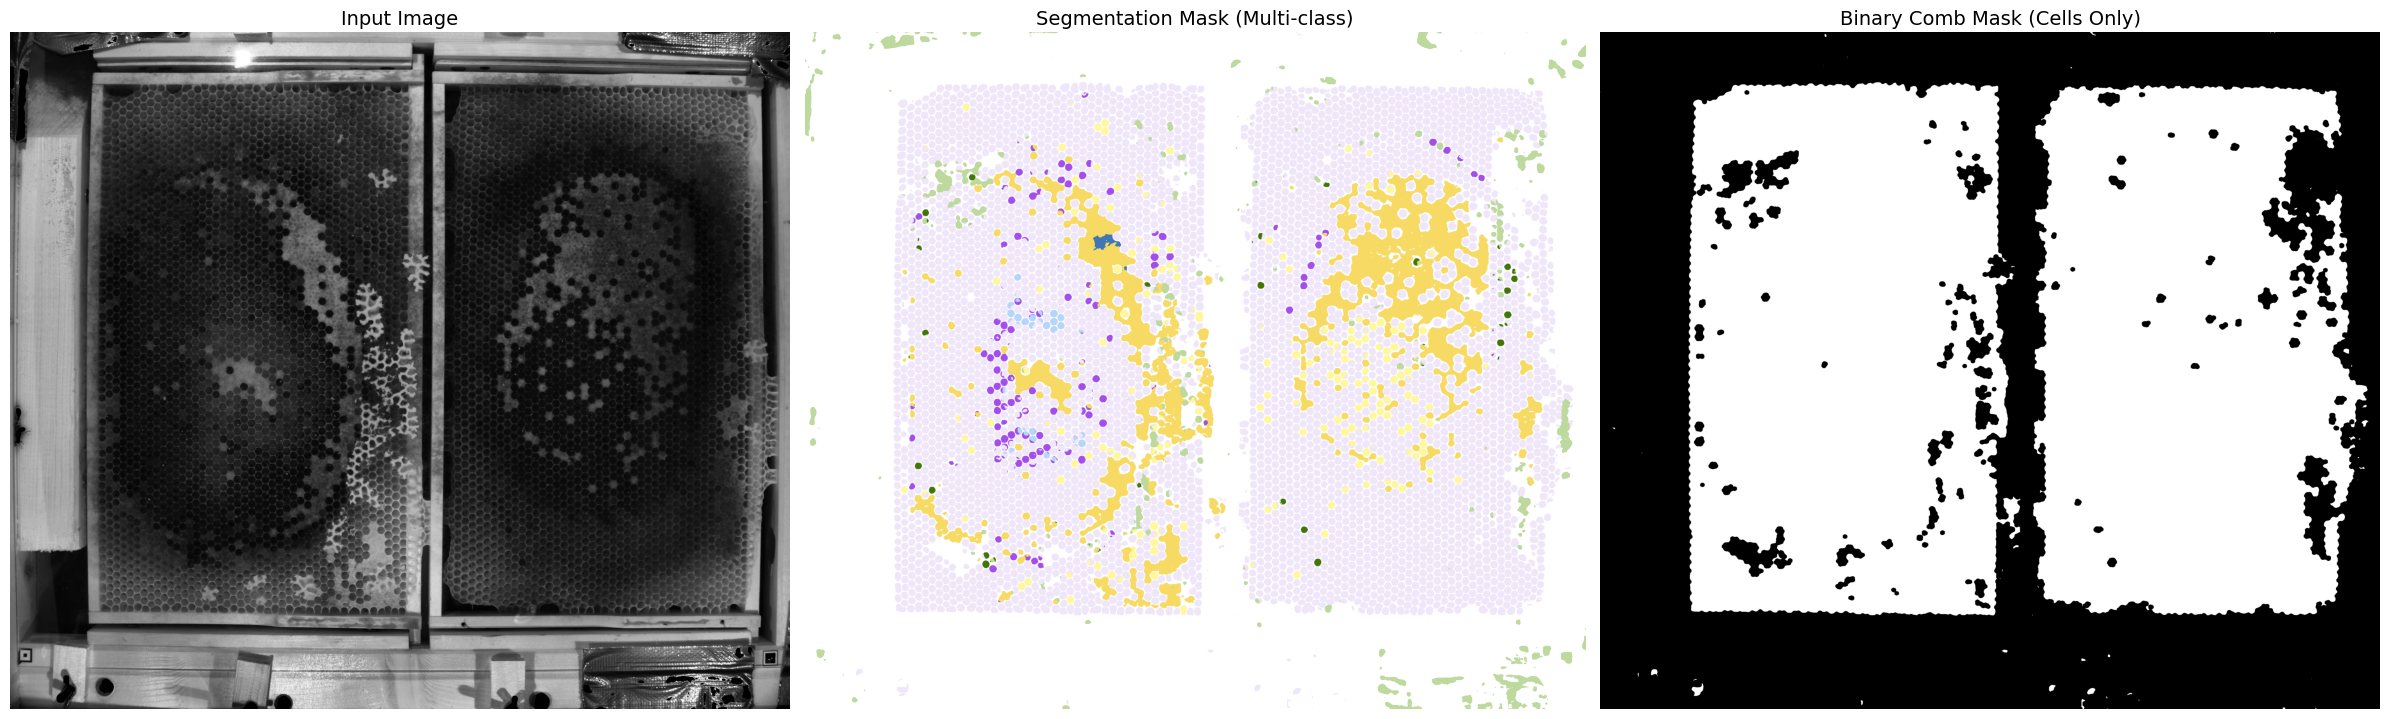

In [8]:
# Visualize: input image, segmentation mask, and binary comb mask
input_img = cv2.imread(str(path), 0)
fig, ax = generator.visualize_comparison(
    pred,
    comb_mask,
    input_image=input_img,
    cmap_colors=model.cmap  # Use the colormap from the model
)
plt.show()

In [ ]:
# Optional: Save the mask
# output_path = root_dir / 'data' / 'comb_masks' / 'binary_comb_mask.png'
# generator.save_mask(comb_mask, str(output_path))

## Experiment with Different Kernel Sizes

Let's see how different closing kernel sizes affect the mask:

In [ ]:
# Compare different kernel sizes
kernel_sizes = [3, 5, 7, 9, 11]
fig, axes = plt.subplots(1, len(kernel_sizes), figsize=(20, 4))

for idx, kernel_size in enumerate(kernel_sizes):
    gen = CombMaskGenerator(closing_kernel_size=kernel_size)
    mask = gen.generate_comb_mask(pred)

    axes[idx].imshow(mask, cmap='gray')
    axes[idx].set_title(f'Kernel Size: {kernel_size}', fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Evaluation Module - Inspect Ground Truth

Let's first inspect the ground truth mask structure:

In [18]:
path = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\images\20240529_cam-2.png")
assert path.is_file()

Found 36 ground truth files

Example GT: 20240529_cam-2.png
Shape: (4608, 5312)
Unique values: [0 1]
Data type: uint8


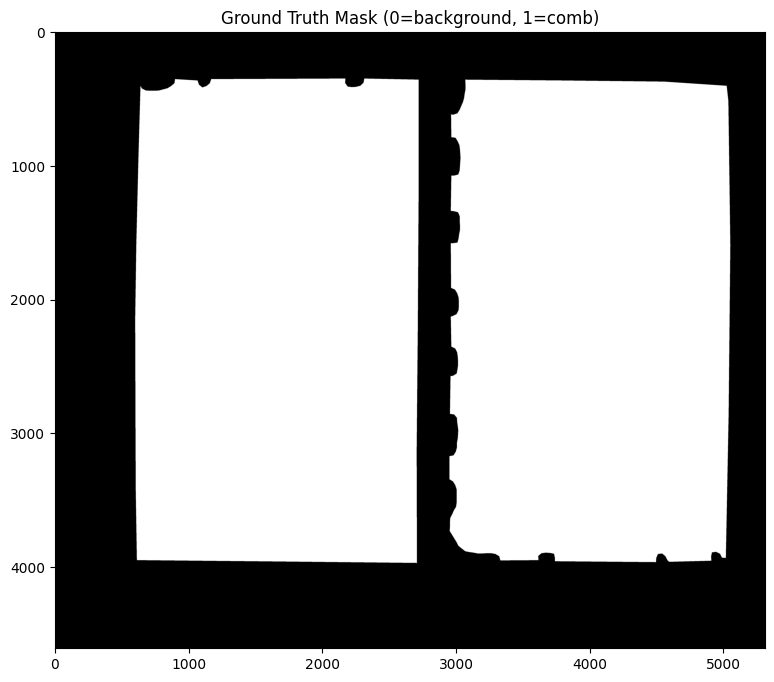

In [19]:
import numpy as np
from pathlib import Path

# Path to ground truth labels
gt_dir = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\labels")

# List available ground truth files
if gt_dir.exists():
    gt_files = list(gt_dir.glob("*.png")) + list(gt_dir.glob("*.jpg"))
    print(f"Found {len(gt_files)} ground truth files")
    if gt_files:
        # Load one example
        example_gt = cv2.imread(str(gt_files[0]), cv2.IMREAD_GRAYSCALE)
        print(f"\nExample GT: {gt_files[0].name}")
        print(f"Shape: {example_gt.shape}")
        print(f"Unique values: {np.unique(example_gt)}")
        print(f"Data type: {example_gt.dtype}")

        # Visualize
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        ax.imshow(example_gt, cmap='gray')
        ax.set_title('Ground Truth Mask (0=background, 1=comb)')
        plt.show()
else:
    print(f"Directory not found: {gt_dir}")

# Evaluation Against Ground Truth

Now let's evaluate the predicted comb mask against ground truth labels:

In [20]:
from segmentation_restruct.comb_limitor import CombMaskEvaluator

# Create evaluator (both predictions and GT are now in 0/1 format!)
evaluator = CombMaskEvaluator()

print("✓ Evaluator initialized")
print("  • Ground truth format: 0 (background) / 1 (comb)")
print("  • Prediction format: 0 (background) / 1 (comb)")
print("  • Both use the same format - direct comparison!")

✓ Evaluator initialized
  • Ground truth format: 0 (background) / 1 (comb)
  • Prediction format: 0 (background) / 1 (comb)
  • Both use the same format - direct comparison!


### Important: Consistent Mask Format

**Your Ground Truth (from CVAT)**:
- Values: **0** (background) and **1** (comb)
- Created from RGB colors: (0,0,0) → 0, (61,245,61) → 1

**Generated Predictions (from `generate_comb_mask`)**:
- Values: **0** (background) and **1** (comb)
- Same format as ground truth for direct comparison! ✅

Both prediction and ground truth now use **0/1 format** - no conversion needed!

In [21]:
# Load a ground truth mask (update the filename to match your data)
gt_dir = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\labels")

# Example: if your ground truth has the same name as the input image
gt_filename = path.stem + ".png"  # Adjust extension if needed
gt_path = gt_dir / gt_filename

if gt_path.exists():
    gt_mask = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
    print(f"✓ Loaded ground truth: {gt_path.name}")
    print(f"  Shape: {gt_mask.shape}")
    print(f"  Unique values: {np.unique(gt_mask)}")
else:
    # List available ground truth files
    available_gts = list(gt_dir.glob("*.png"))
    print(f"Ground truth not found: {gt_path}")
    print(f"\nAvailable ground truth files ({len(available_gts)}):")
    for i, gt_file in enumerate(available_gts[:5]):
        print(f"  {i+1}. {gt_file.name}")
    if len(available_gts) > 5:
        print(f"  ... and {len(available_gts) - 5} more")

    # Load the first available one for demonstration
    if available_gts:
        gt_path = available_gts[0]
        gt_mask = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
        print(f"\n✓ Using first available: {gt_path.name}")

✓ Loaded ground truth: 20240529_cam-2.png
  Shape: (4608, 5312)
  Unique values: [0 1]


In [24]:
# Evaluate the comb mask against ground truth
metrics = evaluator.evaluate(comb_mask, gt_mask)

# Print comprehensive metrics
evaluator.print_metrics(metrics, title="Comb Mask Evaluation")


                    Comb Mask Evaluation                    

Main Metrics:
Accuracy:    0.9419  (94.19%)
IoU:         0.9055  (90.55%)
Dice:        0.9504  (95.04%)
F1 Score:    0.9504  (95.04%)

Precision & Recall:
Precision:   0.9864  (98.64%)
Recall:      0.9170  (91.70%)
Specificity: 0.9804  (98.04%)

Confusion Matrix:
True Positives  (TP): 13,626,711
True Negatives  (TN): 9,429,698
False Positives (FP): 188,043
False Negatives (FN): 1,233,244
Total pixels:         24,477,696



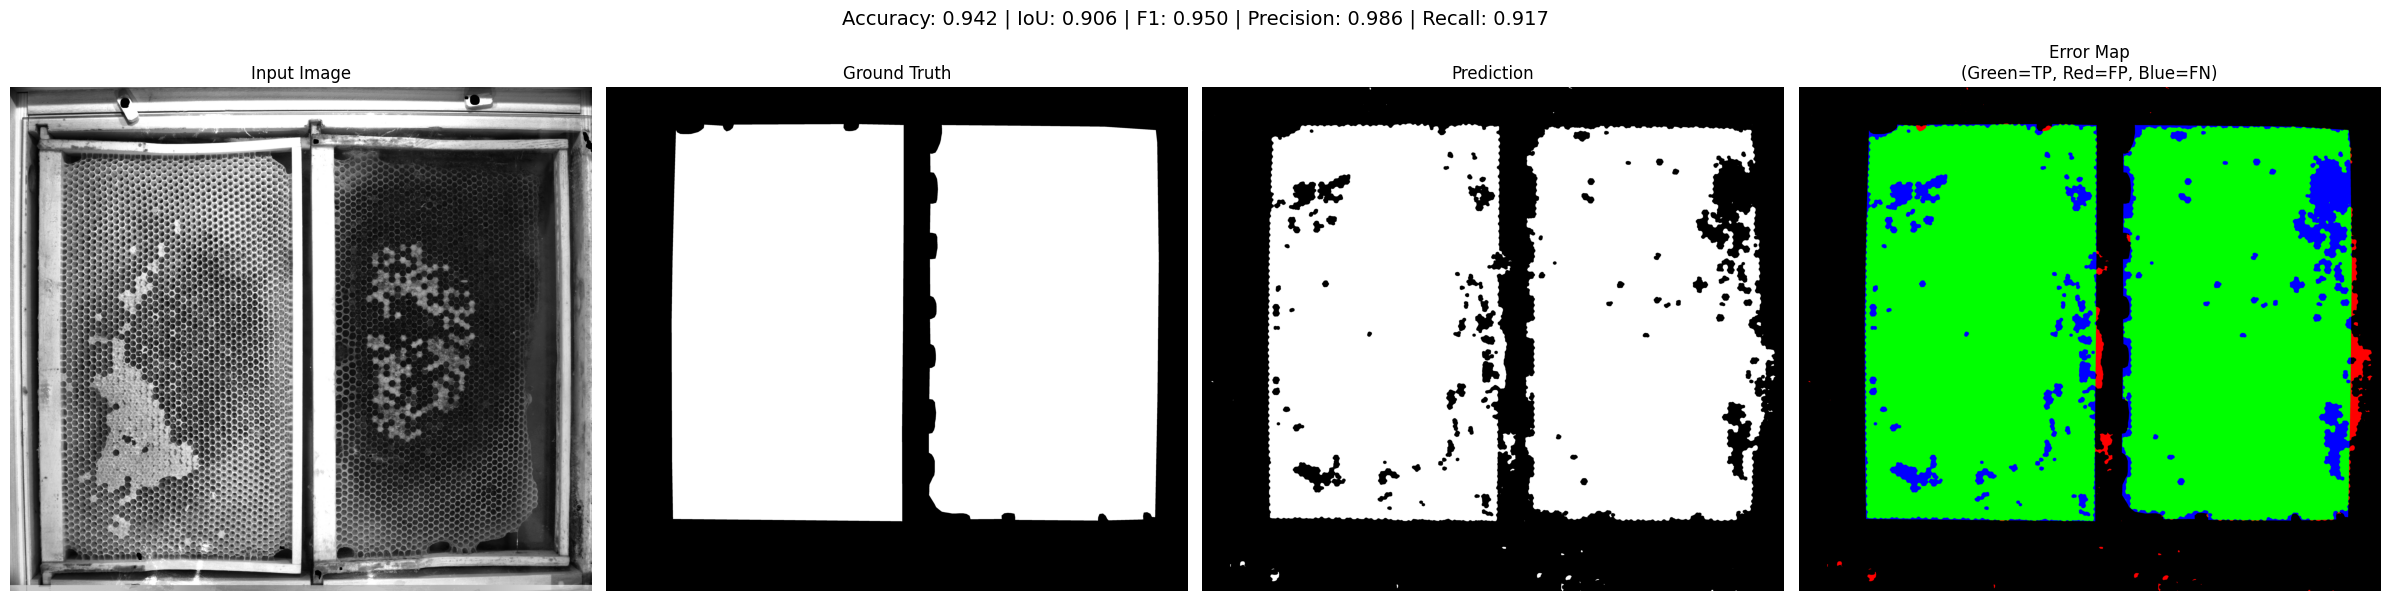

In [25]:
# Visualize prediction vs ground truth with error map
# Error map colors: Green=TP, Red=FP (over-segmentation), Blue=FN (under-segmentation)
fig, axes = evaluator.visualize_prediction(
    comb_mask,
    gt_mask,
    input_image=input_img,
    show_metrics=True
)
plt.show()

## Batch Evaluation (Optional)

If you want to evaluate multiple images at once:

In [ ]:
images_dir = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\images\test")
gt_dir = Path(r"E:\Bachelorarbeit\comb_limitation_dataset\labels\test")

image_files = sorted(images_dir.glob("*.png")) + sorted(images_dir.glob("*.jpg"))
print(f"Found {len(image_files)} images to process")

predicted_masks = []
ground_truth_masks = []
input_images = []
image_names = []

print("\nProcessing images...")
for img_file in image_files:
    # Find corresponding ground truth
    gt_file = gt_dir / img_file.name

    if not gt_file.exists():
        print(f"Skipping {img_file.name} - no ground truth found")
        continue

    print(f"Processing {img_file.name}...")

    input_img = cv2.imread(str(img_file), cv2.IMREAD_GRAYSCALE)

    seg_mask = model.infer(str(img_file))

    pred_mask = generator.generate_comb_mask(seg_mask)

    gt_mask = cv2.imread(str(gt_file), cv2.IMREAD_GRAYSCALE)

    predicted_masks.append(pred_mask)
    ground_truth_masks.append(gt_mask)
    input_images.append(input_img)
    image_names.append(img_file.name)

print(f"\nProcessed {len(predicted_masks)} images successfully")

Found 4 images to process

Processing images...
  Processing 20240606_cam-3.png...
  Processing background_cam-0_20250719T012105.601863.038Z.png...
  Processing background_cam-0_20250719T012105.601863.038Z.png...
  Processing background_cam-3_20250705T043209.571836.965Z.png...
  Processing background_cam-3_20250705T043209.571836.965Z.png...
  Processing k_background_cam-1_20250816T104412.249021.386Z--20250816T104512.171084.576Z.png...
  Processing k_background_cam-1_20250816T104412.249021.386Z--20250816T104512.171084.576Z.png...

✓ Processed 4 images successfully

✓ Processed 4 images successfully


In [30]:
# Evaluate all masks at once
aggregate_metrics, per_image_metrics = evaluator.evaluate_batch_from_arrays(
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    image_names=image_names
)

# Print aggregate results
evaluator.print_metrics(aggregate_metrics, title="Batch Evaluation Results")

# Print per-image results
print("\n" + "="*60)
print("Per-Image Results:")
print("="*60)
for metrics in per_image_metrics:
    print(f"\n{metrics['filename']}:")
    print(f"  IoU: {metrics['iou']:.4f}  |  Dice: {metrics['dice']:.4f}  |  Accuracy: {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}  |  Recall: {metrics['recall']:.4f}")



                  Batch Evaluation Results                  

Aggregate Statistics (n=4 images):

  Main Metrics:
IoU:      0.9288 +/- 0.0446  (range: 0.8516 - 0.9572)
Dice/F1:  0.9625 +/- 0.0247  (range: 0.9198 - 0.9781)
Accuracy: 0.9551 +/- 0.0261  (range: 0.9099 - 0.9722)

  Precision & Recall:
Precision:   0.9923 +/- 0.0031  (range: 0.9881 - 0.9966)
Recall:      0.9355 +/- 0.0448  (range: 0.8582 - 0.9659)
Specificity: 0.9859 +/- 0.0073  (range: 0.9752 - 0.9956)

  Confusion Matrix Totals:
True Positives  (TP): 58,886,819  (avg: 14,721,705 per image)
True Negatives  (TN): 34,627,668  (avg: 8,656,917 per image)
False Positives (FP): 464,750  (avg: 116,188 per image)
False Negatives (FN): 3,931,547  (avg: 982,887 per image)
Total pixels:         97,910,784


Per-Image Results:

20240606_cam-3.png:
  IoU: 0.8516  |  Dice: 0.9198  |  Accuracy: 0.9099
  Precision: 0.9910  |  Recall: 0.8582

background_cam-0_20250719T012105.601863.038Z.png:
  IoU: 0.9547  |  Dice: 0.9768  |  Accuracy: 0.

In [31]:
run_name = "matoschchuk_seg_mask_without_outlier_removal"
# Save batch results with the meaningful run name from above
saved_paths = evaluator.save_batch_results(
    aggregate_metrics=aggregate_metrics,
    per_image_metrics=per_image_metrics,
    output_dir=root_dir / "results",  # Results will be saved in project/results/
    run_name=run_name,  # Using the run_name defined above
    save_figure=True,
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    input_images=input_images,
    image_names=image_names
)

print("\nSaved files:")
for key, path in saved_paths.items():
    print(f"  {key}: {path.name}")


âœ“ Aggregate metrics saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\matoschchuk_seg_mask_without_outlier_removal\aggregate_metrics.json
âœ“ Per-image metrics saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\matoschchuk_seg_mask_without_outlier_removal\per_image_metrics.json
âœ“ Visualization saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\matoschchuk_seg_mask_without_outlier_removal\visualization.png
âœ“ Summary saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\matoschchuk_seg_mask_without_outlier_removal\summary.txt

All results saved to: C:\Users\sturmd\Documents\Privates\honeybee_cells_segmentation_inference\results\matoschchuk_seg_mask_without_outlier_removal


Saved files:
  aggregate: aggregate_metrics.json
  per_image: per_image_metrics.json
  visualization: visualization.png
  summary: summary.txt
âœ“ Visualiz

## Save Batch Results

The results will be saved in a structured folder:
```
results/
  {run_name}/
    ├── aggregate_metrics.json     # Overall statistics
    ├── per_image_metrics.json     # Individual image metrics
    ├── visualization.png          # Grid of all predictions
    └── summary.txt                # Human-readable summary
```

**Tips for choosing a run name:**
- Include model name: `unet_effb0`, `manet_effb0`, etc.
- Include key parameters: `kernel7_iter3`, `kernel11_iter1`, etc.
- Add date/version: `2024-10-25`, `v1`, `baseline`, etc.
- Examples:
  - `unet_effb0_kernel7_baseline`
  - `manet_kernel11_iter3_2024-10-25`
  - `test_run_v1`


In [ ]:
# Examples of different run names for different experiments:
#
# run_name = "baseline_unet_effb0"                      # Initial baseline
# run_name = "kernel7_iter3"                            # Testing morphology params
# run_name = "kernel11_iter1_test_2024-10-25"           # Date-stamped test
# run_name = "manet_effb0_final"                        # Final model version
# run_name = "experiment_01_high_precision"             # Descriptive name

# Choose your run name here:
from datetime import datetime
date_str = datetime.now().strftime("%Y%m%d")
run_name = f"unet_effb0_kernel11_iter3_{date_str}"

print(f"Run name: {run_name}")


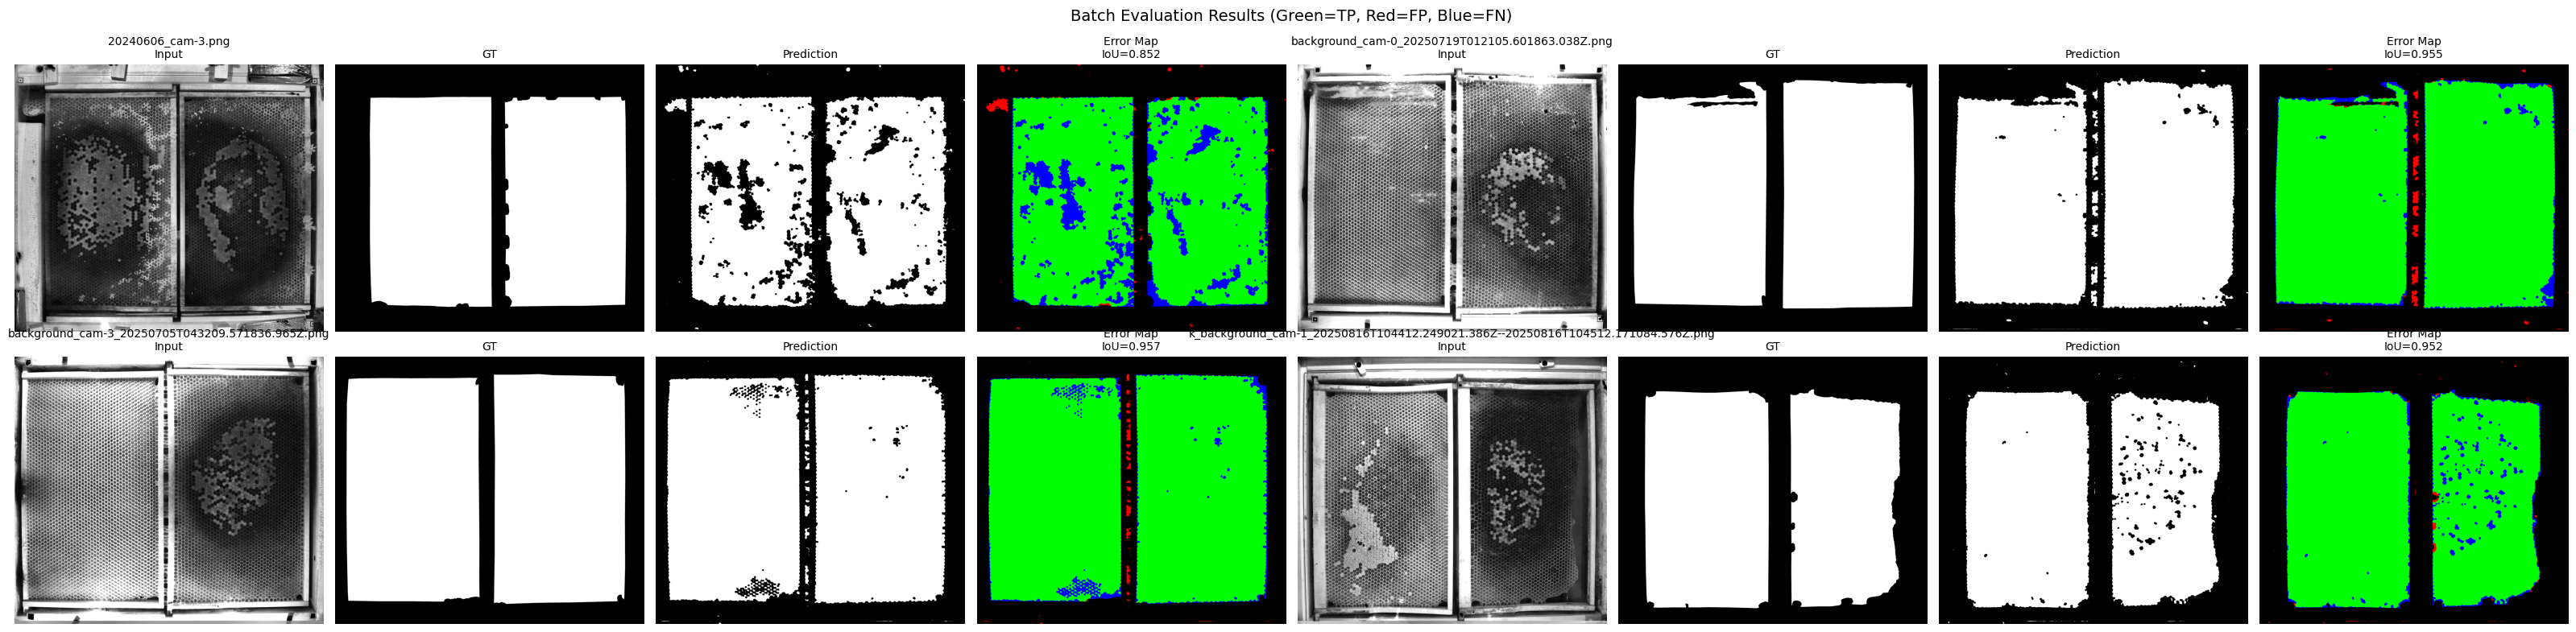

In [17]:
# Visualize all predictions in a grid
fig, axes = evaluator.visualize_batch(
    predicted_masks=predicted_masks,
    ground_truth_masks=ground_truth_masks,
    image_names=image_names,
    input_images=input_images,
    max_cols=2  # 2 images per row
)

# Optionally save the figure
# fig.savefig('batch_evaluation_results.png', dpi=150, bbox_inches='tight')

plt.show()

## Test: Verify Format Handling

Let's verify that the evaluator correctly handles different formats:

In [ ]:
# Create test masks - both now in 0/1 format!
test_gt = np.array([[0, 0, 1, 1], [0, 1, 1, 1], [1, 1, 1, 0], [1, 1, 0, 0]], dtype=np.uint8)
test_pred = np.array([[0, 0, 1, 1], [0, 1, 1, 0], [1, 1, 1, 0], [1, 0, 0, 0]], dtype=np.uint8)

print("Ground Truth (0/1 format):")
print(test_gt)
print(f"Unique values: {np.unique(test_gt)}")

print("\nPrediction (0/1 format - same as GT!):")
print(test_pred)
print(f"Unique values: {np.unique(test_pred)}")

# Evaluate - both formats match!
test_evaluator = CombMaskEvaluator()
test_metrics = test_evaluator.evaluate(test_pred, test_gt, return_confusion_matrix=True)

print("\n✓ Evaluation successful!")
print(f"Accuracy: {test_metrics['accuracy']:.3f}")
print(f"IoU: {test_metrics['iou']:.3f}")
print(f"TP={test_metrics['tp']}, FP={test_metrics['fp']}, FN={test_metrics['fn']}, TN={test_metrics['tn']}")

# Visualize the test
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(test_gt, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Ground Truth (0/1)')
axes[1].imshow(test_pred, cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Prediction (0/1)')

# Error map
error_viz = np.zeros((*test_gt.shape, 3), dtype=np.uint8)
error_viz[(test_pred == 1) & (test_gt == 1)] = [0, 255, 0]  # TP: Green
error_viz[(test_pred == 1) & (test_gt == 0)] = [255, 0, 0]  # FP: Red
error_viz[(test_pred == 0) & (test_gt == 1)] = [0, 0, 255]  # FN: Blue
axes[2].imshow(error_viz)
axes[2].set_title('Error Map (G=TP, R=FP, B=FN)')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()